In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV # GridSearchCV for tuning
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [4]:
dfd = pd.read_csv(r"C:\Users\rishy\Desktop\New folder\infosys\day.csv")
dfh = pd.read_csv(r"C:\Users\rishy\Downloads\ml\hour.csv")




The "Id" variable doesn't provide any meaningful information for the data; it's equivalent to the index, so we'll drop this column.

In [5]:
columns_to_drop_day = ['instant', 'dteday', 'yr', 'casual', 'registered']
dfd.drop(columns=columns_to_drop_day, inplace=True, errors='ignore')






In [6]:

columns_to_drop_hour = ['dteday', 'casual', 'registered', 'yr', 'instant']
dfh = dfh.drop(columns=columns_to_drop_hour, errors='ignore')
dfh = dfh.drop_duplicates()

numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']



In [7]:

def remove_outliers_corrected(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

dfd = remove_outliers_corrected(dfd, numeric_cols)
dfh = remove_outliers_corrected(dfh, numeric_cols)

print("Preprocessing and Outlier Removal Completed.")




Preprocessing and Outlier Removal Completed.


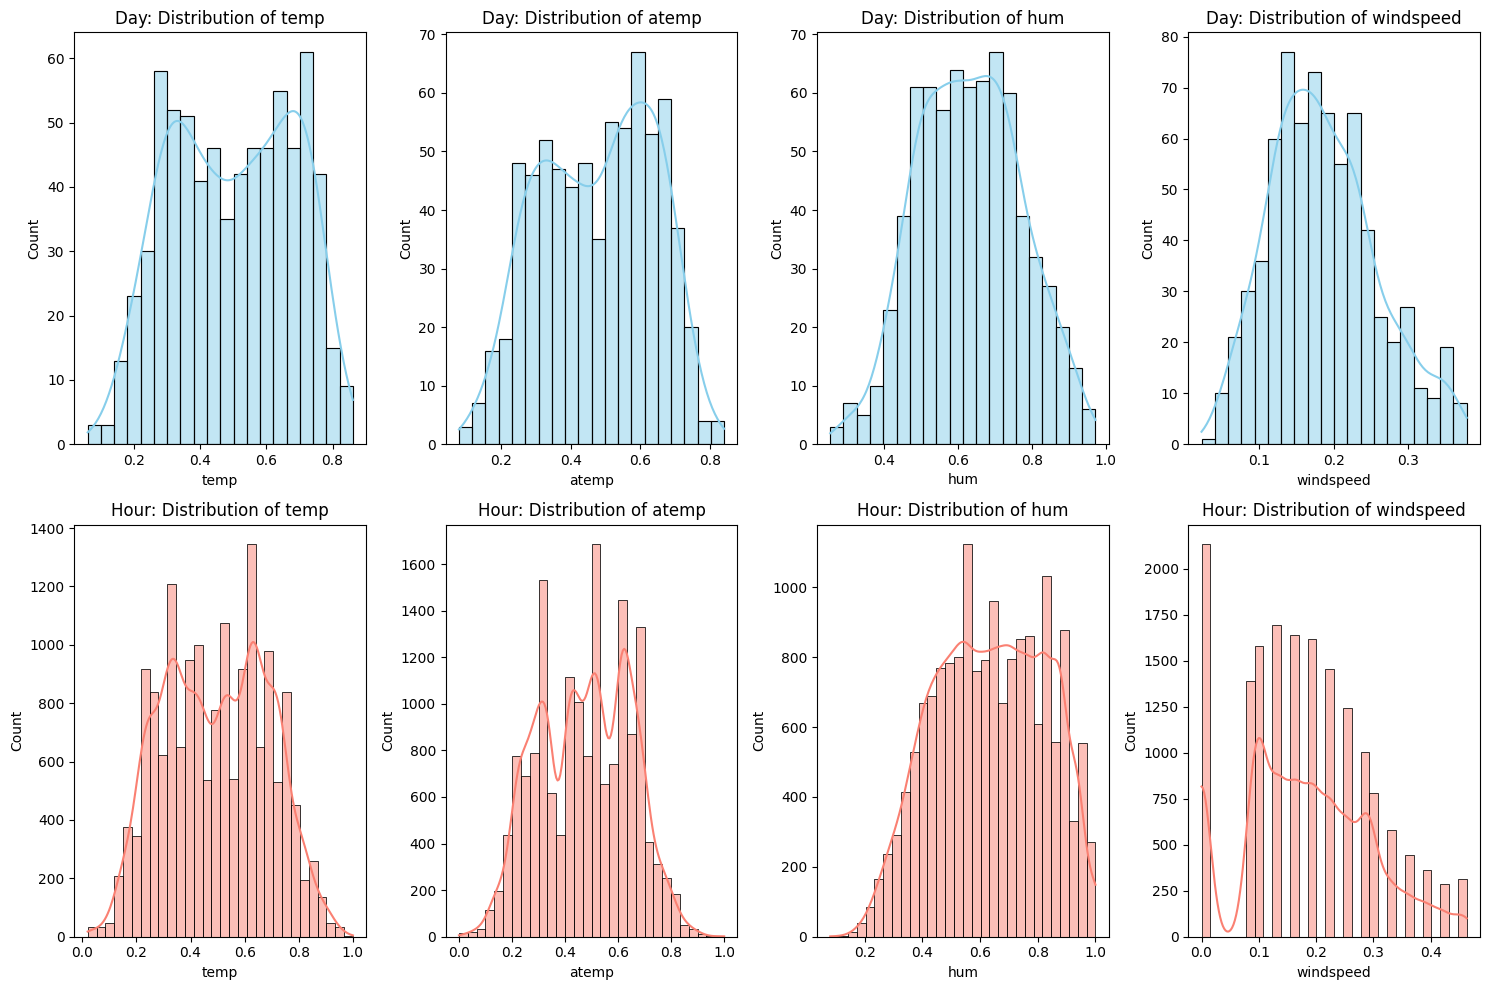

In [9]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols[:-1]): # Exclude 'cnt'
    plt.subplot(2, 4, i + 1)
    sns.histplot(dfd[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Day: Distribution of {col}')

    plt.subplot(2, 4, i + 5)
    sns.histplot(dfh[col], kde=True, bins=30, color='salmon')
    plt.title(f'Hour: Distribution of {col}')

plt.tight_layout()
plt.show()



In [ ]:

X = dfd.drop('cnt', axis=1)
y = dfd['cnt']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


X_h = dfh.drop('cnt', axis=1)
y_h = dfh['cnt']
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)



In [23]:

param_grid_rf = {
    'n_estimators': [100, 200, 300], 
    'max_depth': [10, 15, 20],     
    'min_samples_split': [2, 5]     
}


print("\n--- Starting Day-Wise Random Forest Hyperparameter Tuning ---")

grid_search_day = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=3, 
    scoring='neg_mean_squared_error', 
    verbose=1,
    n_jobs=-1
)

grid_search_day.fit(X_train, y_train)
rf_day_tuned = grid_search_day.best_estimator_

print(f"\nDay-Wise Best Parameters: {grid_search_day.best_params_}")
print(f"Day-Wise Best CV Score (Negative MSE): {grid_search_day.best_score_}")

print("\n--- Starting Hour-Wise Random Forest Hyperparameter Tuning ---")

grid_search_hour = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search_hour.fit(X_train_h, y_train_h)
rf_hour_tuned = grid_search_hour.best_estimator_

print(f"\nHour-Wise Best Parameters: {grid_search_hour.best_params_}")
print(f"Hour-Wise Best CV Score (Negative MSE): {grid_search_hour.best_score_}")




--- Starting Day-Wise Random Forest Hyperparameter Tuning ---
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Day-Wise Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
Day-Wise Best CV Score (Negative MSE): -1506353.3725140311

--- Starting Hour-Wise Random Forest Hyperparameter Tuning ---
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Hour-Wise Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
Hour-Wise Best CV Score (Negative MSE): -3612.8756407976866


In [22]:

pred_rf_day = rf_day_tuned.predict(X_test)
pred_rf_hour = rf_hour_tuned.predict(X_test_h)


lr_day = LinearRegression()
lr_day.fit(X_train, y_train)
pred_lr_day = lr_day.predict(X_test)

lr_hour = LinearRegression()
lr_hour.fit(X_train_h, y_train_h)
pred_lr_hour = lr_hour.predict(X_test_h)

print("\nModels Trained (Random Forest Tuned).")




Models Trained (Random Forest Tuned).


In [13]:
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n--- {model_name} Performance ---")
    print(f"  R-squared (Accuracy Metric): {r2:.4f}")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"  Mean Absolute Error (MAE): {mae:.2f}")
    return r2

print("\n==============================================")
print("       Tuned Model Evaluation Results         ")
print("==============================================")

r2_rf_day_tuned = evaluate_model(y_test, pred_rf_day, "DAY-WISE Random Forest (Tuned)")
r2_lr_day = evaluate_model(y_test, pred_lr_day, "DAY-WISE Linear Regression")

r2_rf_hour_tuned = evaluate_model(y_test_h, pred_rf_hour, "HOUR-WISE Random Forest (Tuned)")
r2_lr_hour = evaluate_model(y_test_h, pred_lr_hour, "HOUR-WISE Linear Regression")



       Tuned Model Evaluation Results         

--- DAY-WISE Random Forest (Tuned) Performance ---
  R-squared (Accuracy Metric): 0.6534
  Mean Squared Error (MSE): 1305349.36
  Root Mean Squared Error (RMSE): 1142.52
  Mean Absolute Error (MAE): 967.13

--- DAY-WISE Linear Regression Performance ---
  R-squared (Accuracy Metric): 0.5712
  Mean Squared Error (MSE): 1615096.62
  Root Mean Squared Error (RMSE): 1270.86
  Mean Absolute Error (MAE): 1075.67

--- HOUR-WISE Random Forest (Tuned) Performance ---
  R-squared (Accuracy Metric): 0.8647
  Mean Squared Error (MSE): 3249.02
  Root Mean Squared Error (RMSE): 57.00
  Mean Absolute Error (MAE): 38.04

--- HOUR-WISE Linear Regression Performance ---
  R-squared (Accuracy Metric): 0.3454
  Mean Squared Error (MSE): 15717.51
  Root Mean Squared Error (RMSE): 125.37
  Mean Absolute Error (MAE): 95.04


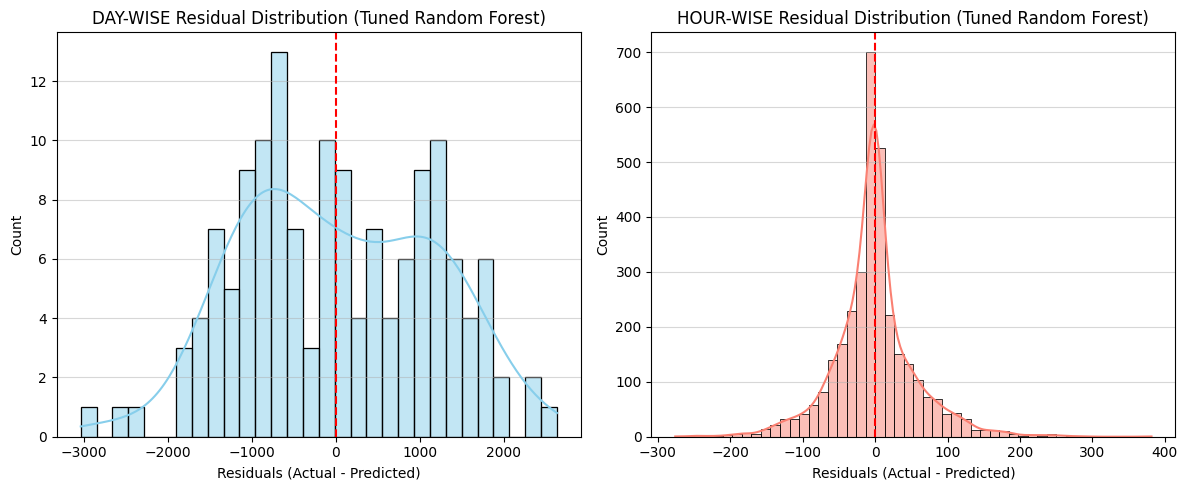

In [14]:
residuals_rf_day = y_test - pred_rf_day
residuals_rf_hour = y_test_h - pred_rf_hour

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(residuals_rf_day, kde=True, bins=30, color='skyblue')
plt.title("DAY-WISE Residual Distribution (Tuned Random Forest)")
plt.xlabel("Residuals (Actual - Predicted)")
plt.axvline(0, color='red', linestyle='--')
plt.grid(axis='y', alpha=0.5)

plt.subplot(1, 2, 2)
sns.histplot(residuals_rf_hour, kde=True, bins=50, color='salmon')
plt.title("HOUR-WISE Residual Distribution (Tuned Random Forest)")
plt.xlabel("Residuals (Actual - Predicted)")
plt.axvline(0, color='red', linestyle='--')
plt.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()


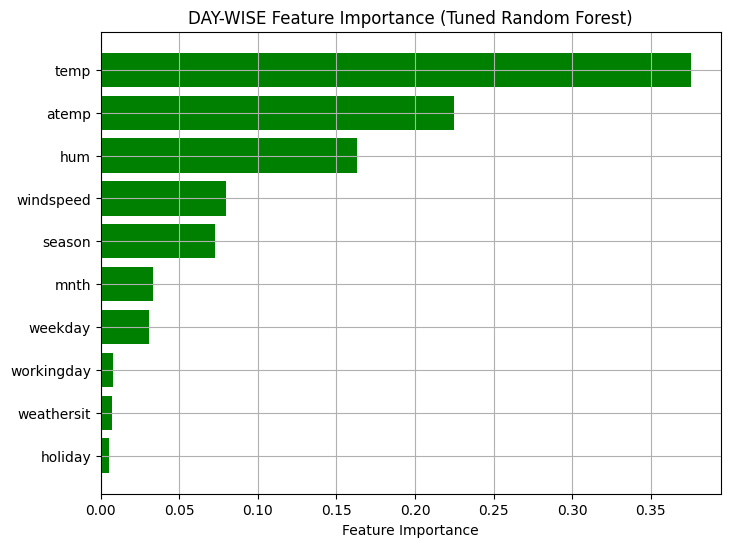

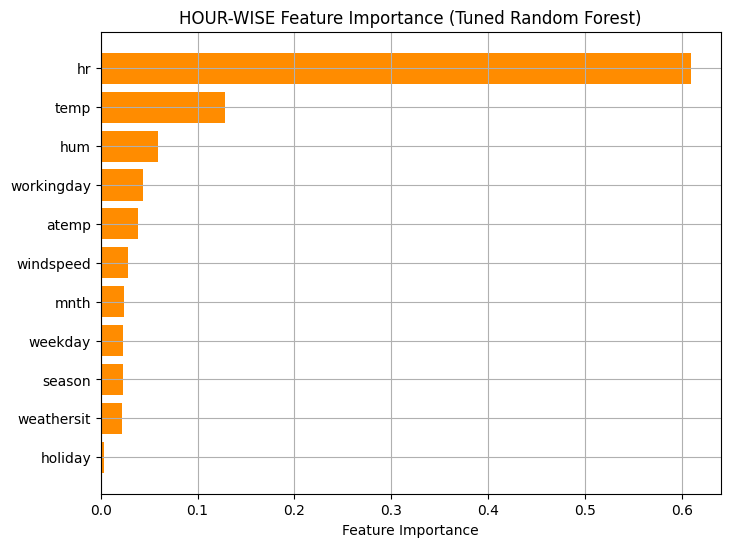

In [21]:

importances_day = rf_day_tuned.feature_importances_
feature_names_day = X.columns
fi_day = pd.DataFrame({'Feature': feature_names_day, 'Importance': importances_day}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(8,6))
plt.barh(fi_day['Feature'], fi_day['Importance'], color='green')
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("DAY-WISE Feature Importance (Tuned Random Forest)")
plt.grid(True)
plt.show()
importances_hour = rf_hour_tuned.feature_importances_
feature_names_hour = X_h.columns
fi_hour = pd.DataFrame({'Feature': feature_names_hour, 'Importance': importances_hour}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(8,6))
plt.barh(fi_hour['Feature'], fi_hour['Importance'], color='darkorange')
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("HOUR-WISE Feature Importance (Tuned Random Forest)")
plt.grid(True)
plt.show()




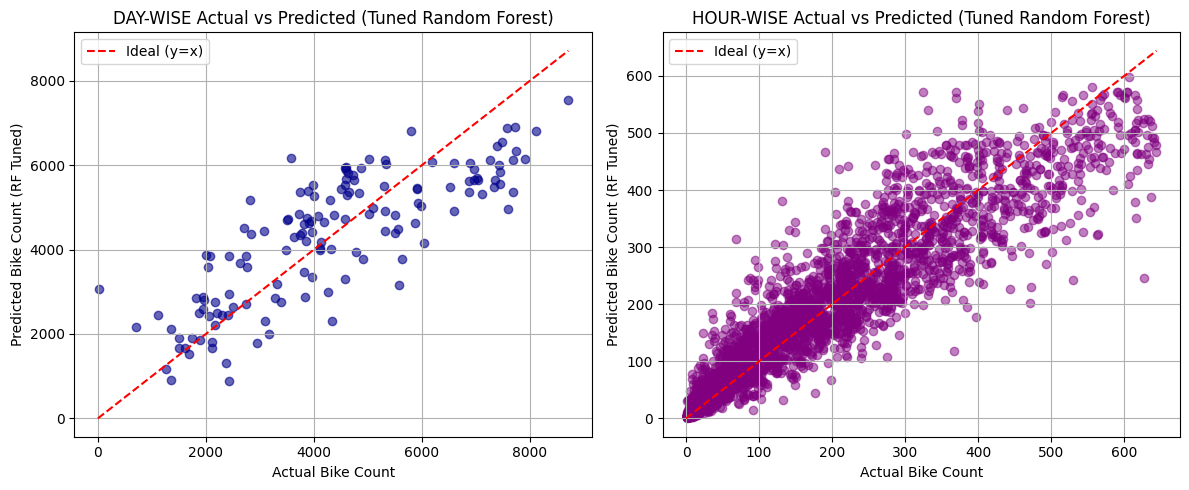

In [ ]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test.values, pred_rf_day, alpha=0.6, color='darkblue')
max_val_day = max(y_test.max(), pred_rf_day.max())
plt.plot([0, max_val_day], [0, max_val_day], 'r--', label='Ideal (y=x)')
plt.xlabel("Actual Bike Count")
plt.ylabel("Predicted Bike Count (RF Tuned)")
plt.title("DAY-WISE Actual vs Predicted (Tuned Random Forest)")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test_h.values, pred_rf_hour, alpha=0.5, color='purple')
max_val_hour = max(y_test_h.max(), pred_rf_hour.max())
plt.plot([0, max_val_hour], [0, max_val_hour], 'r--', label='Ideal (y=x)')
plt.xlabel("Actual Bike Count")
plt.ylabel("Predicted Bike Count (RF Tuned)")
plt.title("HOUR-WISE Actual vs Predicted (Tuned Random Forest)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



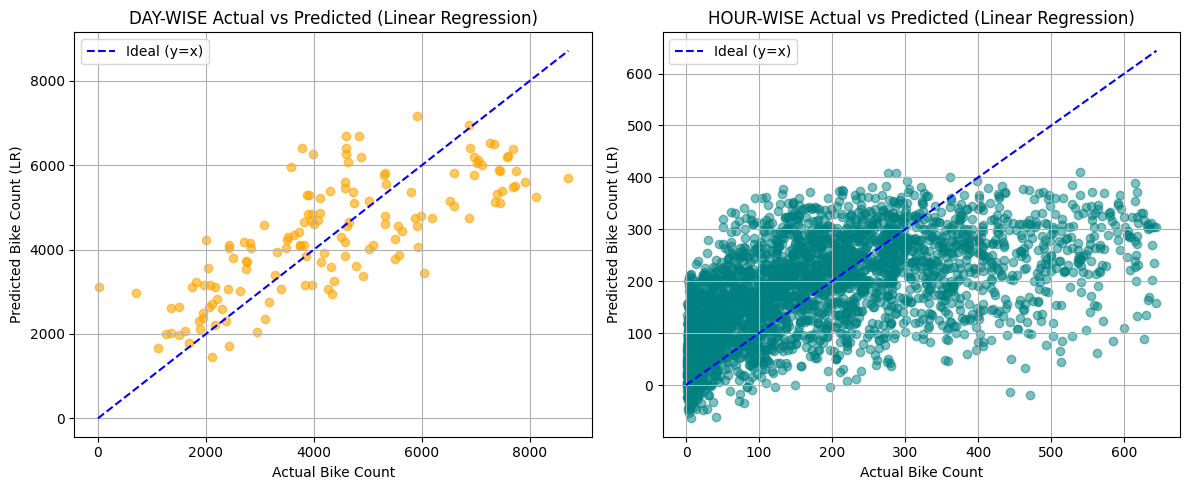


All new diagrams have been generated.
Hyperparameter Tuning for Random Forest Regressor is complete, and the tuned models are now used for predictions.


In [20]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test.values, pred_lr_day, alpha=0.6, color='orange')
max_val_day = max(y_test.max(), pred_lr_day.max())
plt.plot([0, max_val_day], [0, max_val_day], 'b--', label='Ideal (y=x)')
plt.xlabel("Actual Bike Count")
plt.ylabel("Predicted Bike Count (LR)")
plt.title("DAY-WISE Actual vs Predicted (Linear Regression)")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test_h.values, pred_lr_hour, alpha=0.5, color='teal')
max_val_hour = max(y_test_h.max(), pred_lr_hour.max())
plt.plot([0, max_val_hour], [0, max_val_hour], 'b--', label='Ideal (y=x)')
plt.xlabel("Actual Bike Count")
plt.ylabel("Predicted Bike Count (LR)")
plt.title("HOUR-WISE Actual vs Predicted (Linear Regression)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("\nAll new diagrams have been generated.")
print("Hyperparameter Tuning for Random Forest Regressor is complete, and the tuned models are now used for predictions.")
